# Análise Exploratória de Dados - SINAN Esquistossomose

Este notebook realiza uma análise exploratória dos dados processados da SINAN sobre Esquistossomose.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Configurações de plotagem
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

## 1. Carregamento dos Dados

In [2]:
data_path = Path("../data/processed/sinan_esqu_unsup.parquet")
df = pd.read_parquet(data_path)

print(f"Formato do dataset: {df.shape}")
df.head()

Formato do dataset: (135084, 19)


,ID_AGRAVO,DT_NOTIFIC,SG_UF_NOT,ID_MUNICIP,ID_UNIDADE,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,TRATAM,FORMA,COUFINF,DOENCA_TRA,EVOLUCAO,AN_QUALI,IDADE_PROCESSADA,delay_notificacao_dias,tempo_encerramento_dias
0,B659,2007-10-30,26,260765,2429020,F,5,1,2,26,1,1,26,2,1,1,24.0,111,57.0
1,B659,2007-10-31,29,291760,4027868,F,6,4,2,29,1,1,31,2,<NA>,<NA>,30.0,31,68.0
2,B659,2007-10-10,29,291760,4027914,F,6,4,1,29,1,1,31,2,<NA>,<NA>,49.0,3,NaN
3,B659,2007-10-16,29,291760,4027914,M,6,2,2,29,1,1,31,2,<NA>,<NA>,40.0,26,NaN
4,B659,2007-10-01,29,291760,4027914,M,6,4,3,29,1,1,31,2,<NA>,<NA>,13.0,4,NaN


## 2. Visão Geral e Estatísticas Descritivas

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135084 entries, 0 to 135083
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   ID_AGRAVO                135084 non-null  string        
 1   DT_NOTIFIC               135084 non-null  datetime64[ns]
 2   SG_UF_NOT                135084 non-null  string        
 3   ID_MUNICIP               135084 non-null  string        
 4   ID_UNIDADE               135084 non-null  string        
 5   CS_SEXO                  135084 non-null  string        
 6   CS_GESTANT               135084 non-null  string        
 7   CS_RACA                  135084 non-null  string        
 8   CS_ESCOL_N               135084 non-null  string        
 9   SG_UF                    135084 non-null  string        
 10  TRATAM                   135084 non-null  string        
 11  FORMA                    135084 non-null  string        
 12  COUFINF         

In [4]:
df.describe(include='all')

,ID_AGRAVO,DT_NOTIFIC,SG_UF_NOT,ID_MUNICIP,ID_UNIDADE,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,TRATAM,FORMA,COUFINF,DOENCA_TRA,EVOLUCAO,AN_QUALI,IDADE_PROCESSADA,delay_notificacao_dias,tempo_encerramento_dias
count,135084,135084,135084,135084,135084,135084,135084,135084,135084,135084,135084,135084,135084,135084,82629,79806,135084.000000,135084.000000,117907.000000
unique,1,NaN,27,2163,9989,2,6,5,10,27,4,5,27,2,4,2,NaN,NaN,NaN
top,B659,NaN,31,310620,2209918,M,6,4,1,31,1,1,31,2,1,1,NaN,NaN,NaN
freq,135084,NaN,71466,2628,1824,82297,102445,89197,69338,71603,128696,125490,95474,127434,80575,62463,NaN,NaN,NaN
mean,NaN,2011-11-17 06:32:23.110952960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.412705,26.328270,26.409874
min,NaN,2007-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,2008-05-14 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,0.000000,0.000000
50%,NaN,2010-08-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,11.000000,7.000000
75%,NaN,2013-10-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,41.000000,47.000000
max,NaN,2025-07-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.000000,145.000000,157.000000


## 3. Análise de Valores Faltantes

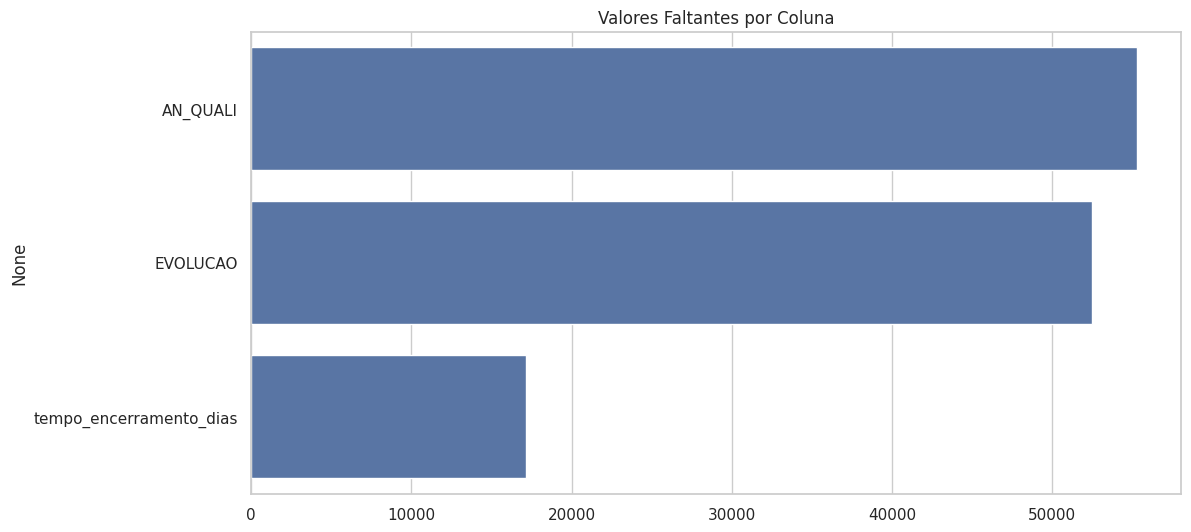

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    sns.barplot(x=missing.values, y=missing.index)
    plt.title("Valores Faltantes por Coluna")
    plt.show()
else:
    print("Não há valores faltantes no dataset.")

## 4. Distribuição das Variáveis Categóricas

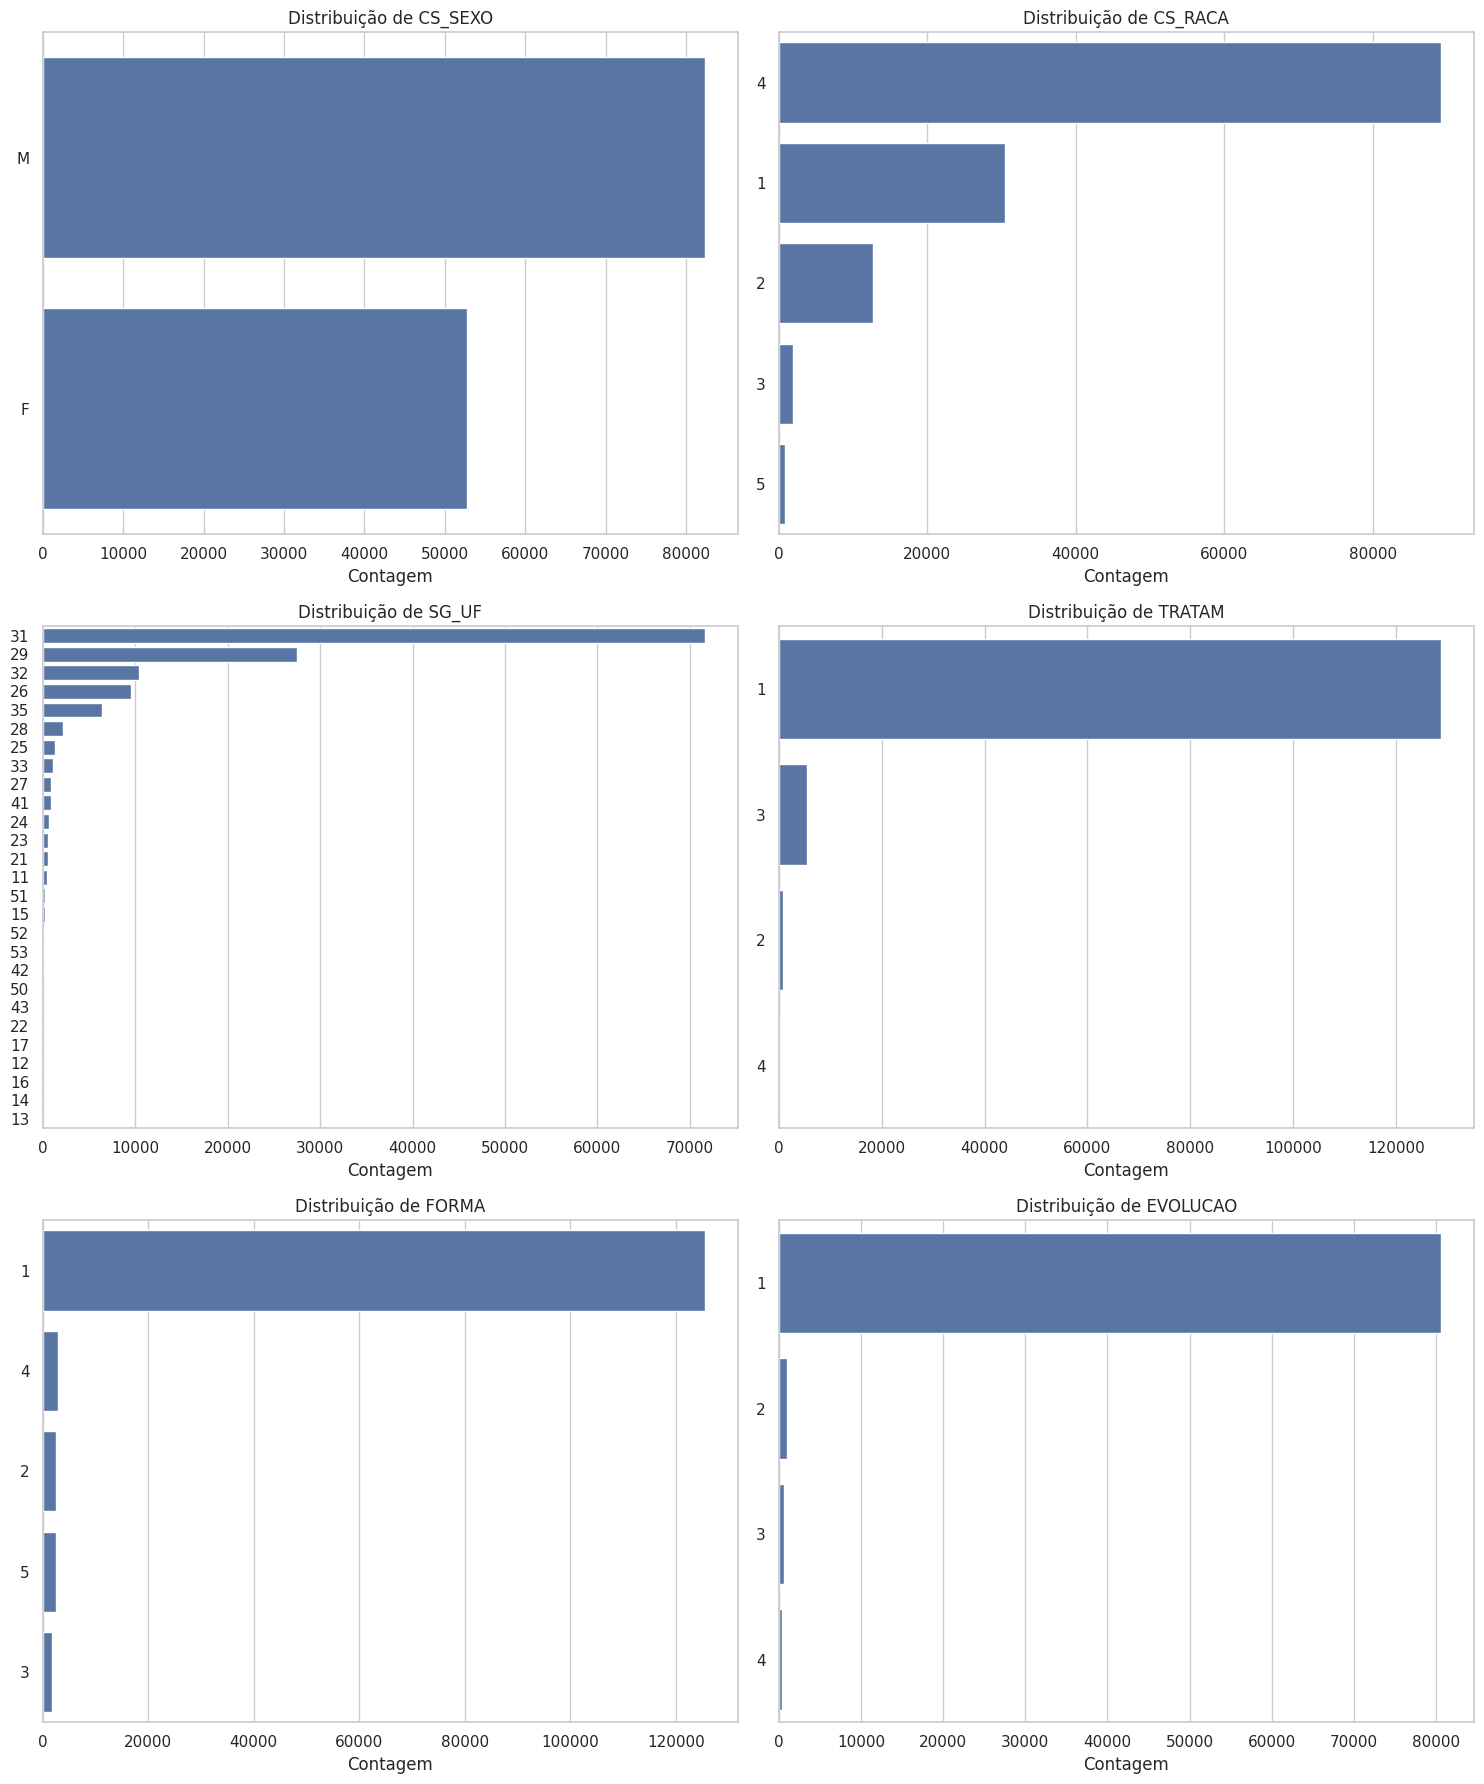

In [6]:
cat_cols = ['CS_SEXO', 'CS_RACA', 'SG_UF', 'TRATAM', 'FORMA', 'EVOLUCAO']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, y=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel('Contagem')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Distribuição das Variáveis Numéricas

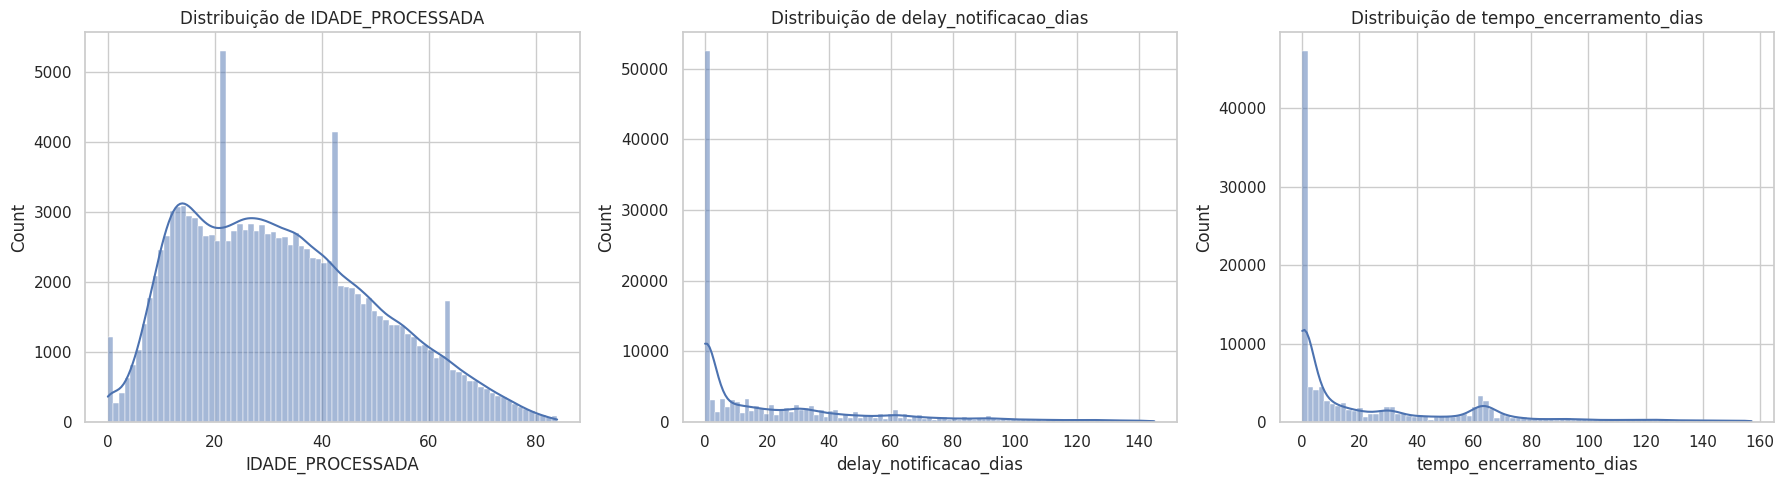

In [7]:
num_cols = ['IDADE_PROCESSADA', 'delay_notificacao_dias', 'tempo_encerramento_dias']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribuição de {col}')

plt.tight_layout()
plt.show()

## 6. Análise Temporal

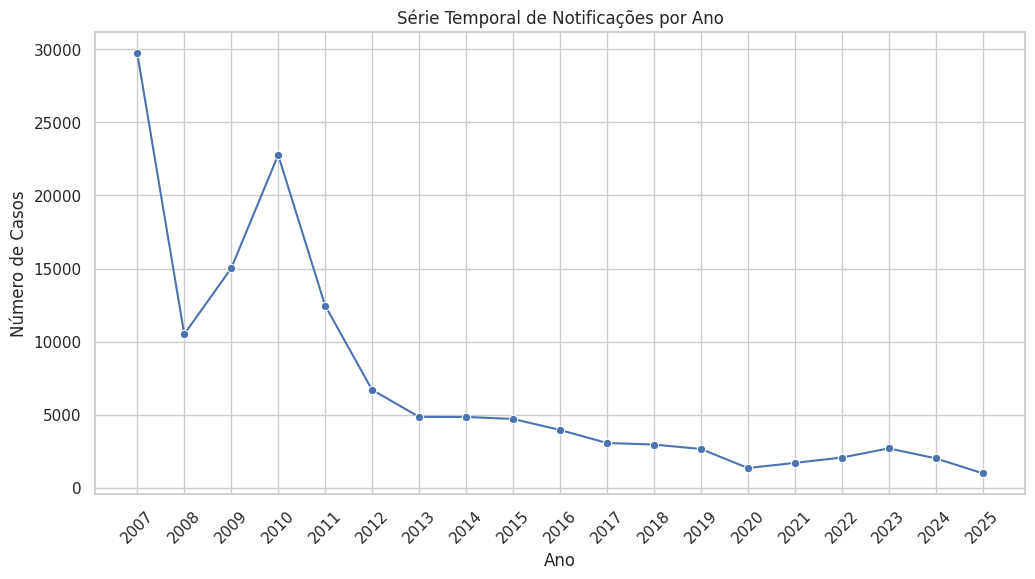

In [8]:
df['ano_notific'] = df['DT_NOTIFIC'].dt.year
df['mes_notific'] = df['DT_NOTIFIC'].dt.month

ts_ano = df.groupby('ano_notific').size()

sns.lineplot(x=ts_ano.index, y=ts_ano.values, marker='o')
plt.title('Série Temporal de Notificações por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Casos')
plt.xticks(ts_ano.index, rotation=45)
plt.show()

## 7. Análise de Correlação / Relações Bivariadas

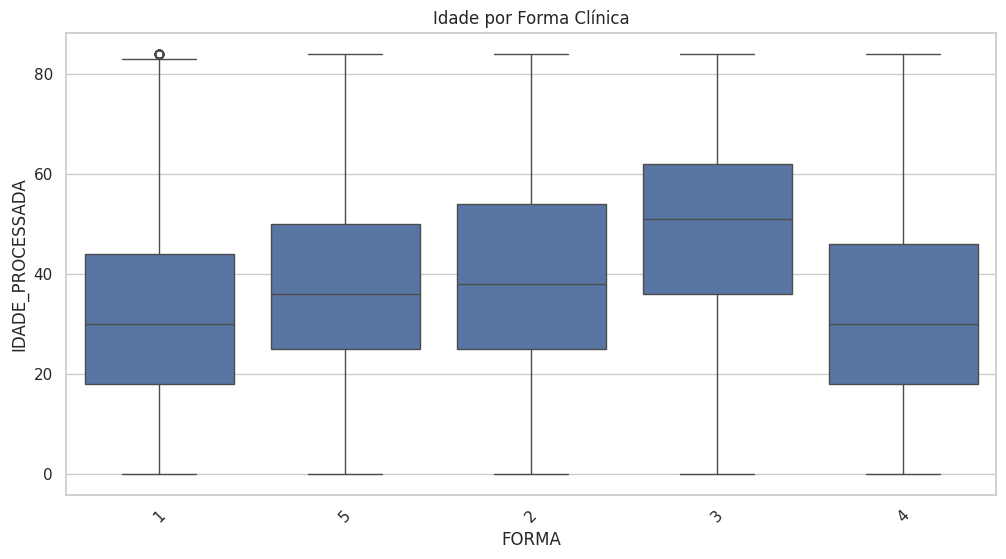

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='FORMA', y='IDADE_PROCESSADA')
plt.title('Idade por Forma Clínica')
plt.xticks(rotation=45)
plt.show()

## 8. Perspectiva não supervisionada (Intro)

Para uma análise não supervisionada, poderíamos aplicar técnicas como PCA ou Clustering após codificação das variáveis categóricas.

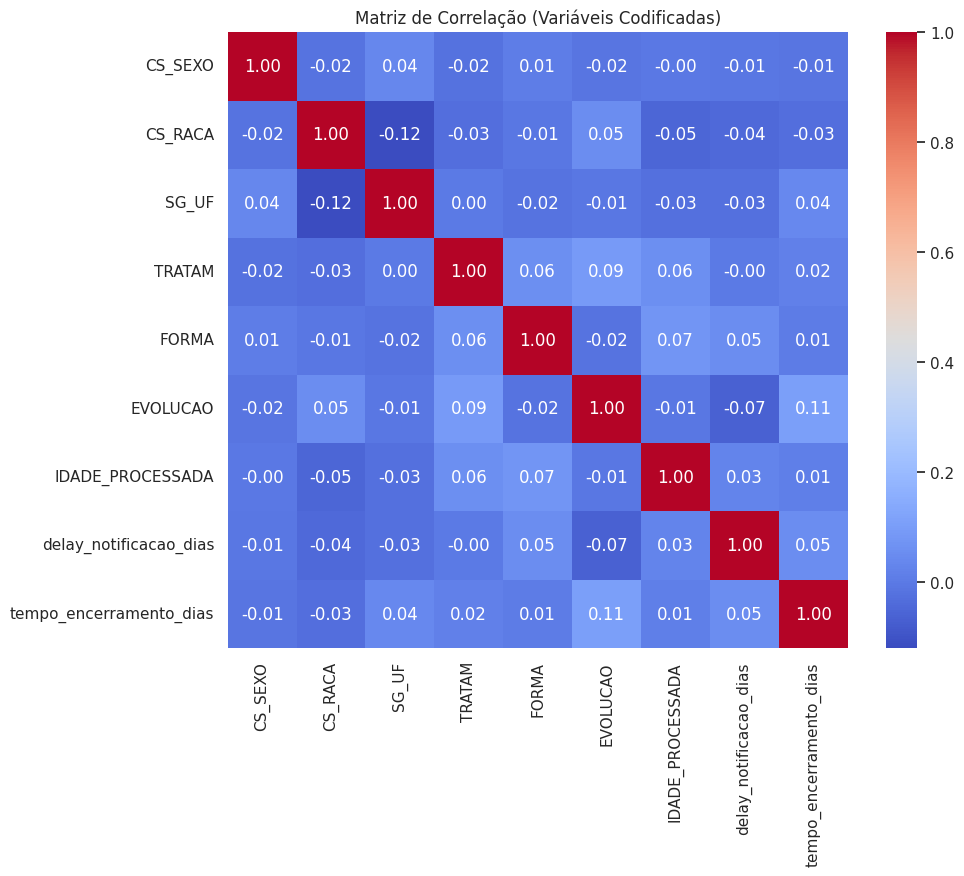

In [10]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df[cat_cols + num_cols].copy()
for col in cat_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação (Variáveis Codificadas)')
plt.show()